<a href="https://colab.research.google.com/github/HariNiveditha/RideDemandForecast/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_path = "/content/drive/MyDrive/RideDemandForecast"

print(os.path.exists(base_path))
print(os.listdir(base_path))

True
['nyc%202021-01-01%20to%202021-12-31.csv', 'taxi_zone_lookup.csv', 'fhvhv_tripdata_2021-05.parquet', 'fhvhv_tripdata_2021-04.parquet', 'fhvhv_tripdata_2021-06.parquet', 'weather_cleaned.parquet', 'hourly_demand_04.parquet', 'hourly_demand_05.parquet', 'hourly_demand_06.parquet', 'data_loading&cleaning.ipynb', 'EDA.ipynb']


In [ ]:
import pandas as pd

april = pd.read_parquet(f"{base_path}/hourly_demand_04.parquet")
may = pd.read_parquet(f"{base_path}/hourly_demand_05.parquet")
june = pd.read_parquet(f"{base_path}/hourly_demand_06.parquet")

trip_df = pd.concat(
    [april, may, june],
    ignore_index=True
)

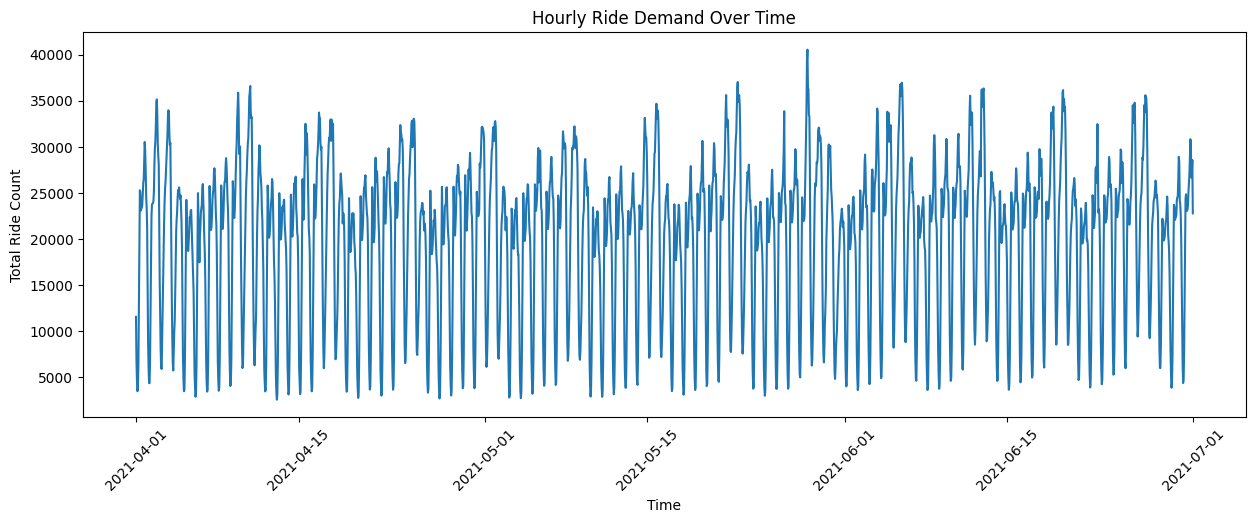

In [ ]:
import matplotlib.pyplot as plt
total_hourly = (
    trip_df.groupby("pickup_hour")["ride_count"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,5))
plt.plot(total_hourly["pickup_hour"], total_hourly["ride_count"])
plt.xlabel("Time")
plt.ylabel("Total Ride Count")
plt.title("Hourly Ride Demand Over Time")
plt.xticks(rotation=45)
plt.show()

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

base_path = "/content/drive/MyDrive/RideDemandForecast"

april = pd.read_parquet(f"{base_path}/hourly_demand_04.parquet")
may = pd.read_parquet(f"{base_path}/hourly_demand_05.parquet")
june = pd.read_parquet(f"{base_path}/hourly_demand_06.parquet")

trip_df = pd.concat(
    [april, may, june],
    ignore_index=True
)

print(trip_df.shape)

(550297, 3)


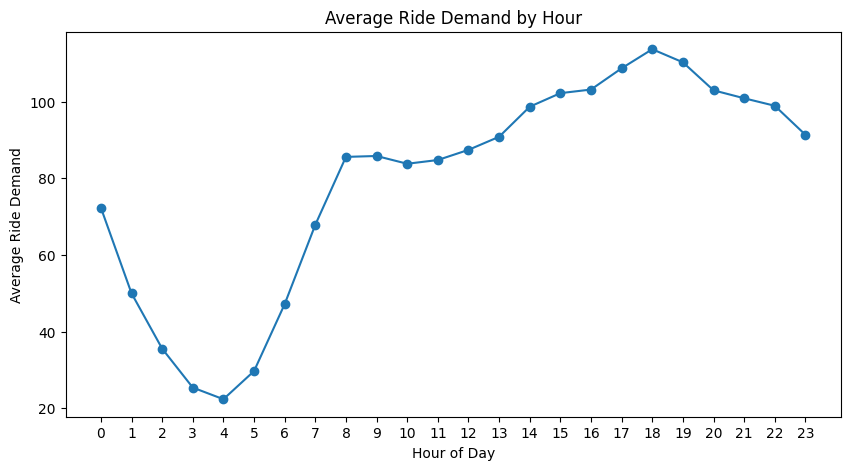

In [8]:
import matplotlib.pyplot as plt

hourly_avg = (
    trip_df.assign(hour=trip_df["pickup_hour"].dt.hour)
    .groupby("hour")["ride_count"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Ride Demand")
plt.title("Average Ride Demand by Hour")
plt.xticks(range(24))
plt.show()

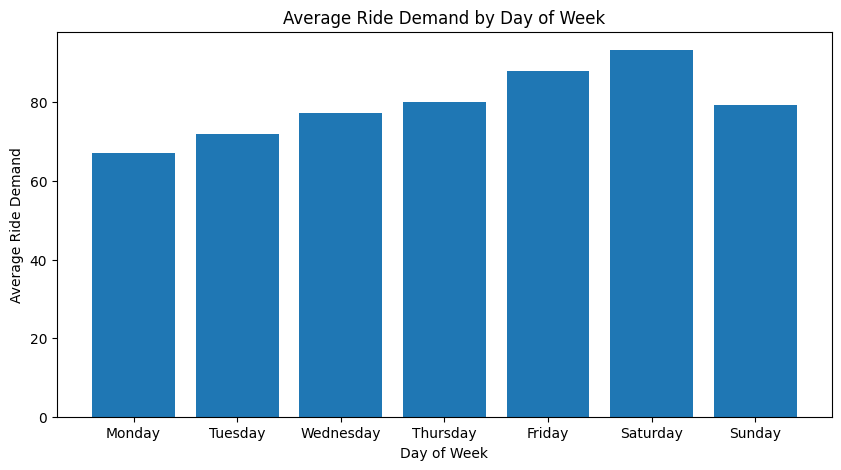

In [9]:
day_avg = (
    trip_df.assign(day_of_week=trip_df["pickup_hour"].dt.dayofweek)
    .groupby("day_of_week")["ride_count"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.bar(day_avg.index, day_avg.values)

plt.xlabel("Day of Week")
plt.ylabel("Average Ride Demand")
plt.title("Average Ride Demand by Day of Week")

plt.xticks(
    range(7),
    ["Monday", "Tuesday", "Wednesday", "Thursday",
     "Friday", "Saturday", "Sunday"]
)

plt.show()

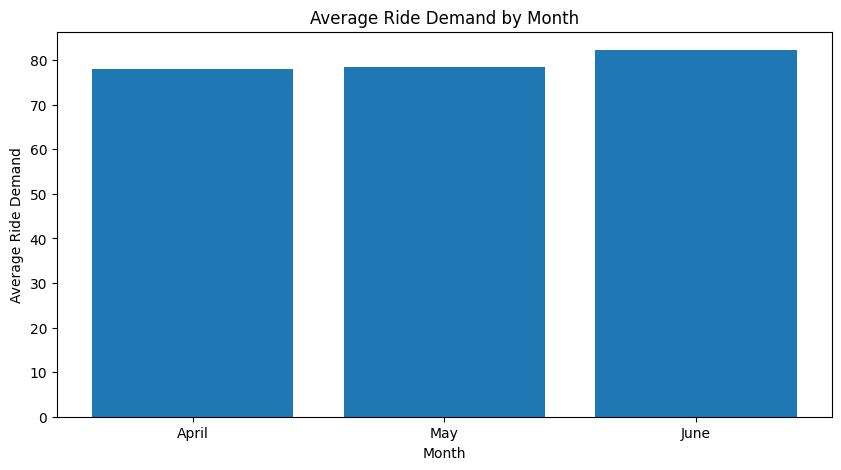

In [12]:
month_avg = (
    trip_df.assign(month=trip_df["pickup_hour"].dt.month)
    .groupby("month")["ride_count"]
    .mean()
)

plt.figure(figsize=(10, 5))
plt.bar(month_avg.index, month_avg.values)

plt.xlabel("Month")
plt.ylabel("Average Ride Demand")
plt.title("Average Ride Demand by Month")

plt.xticks(month_avg.index, ["April", "May", "June"])

plt.show()

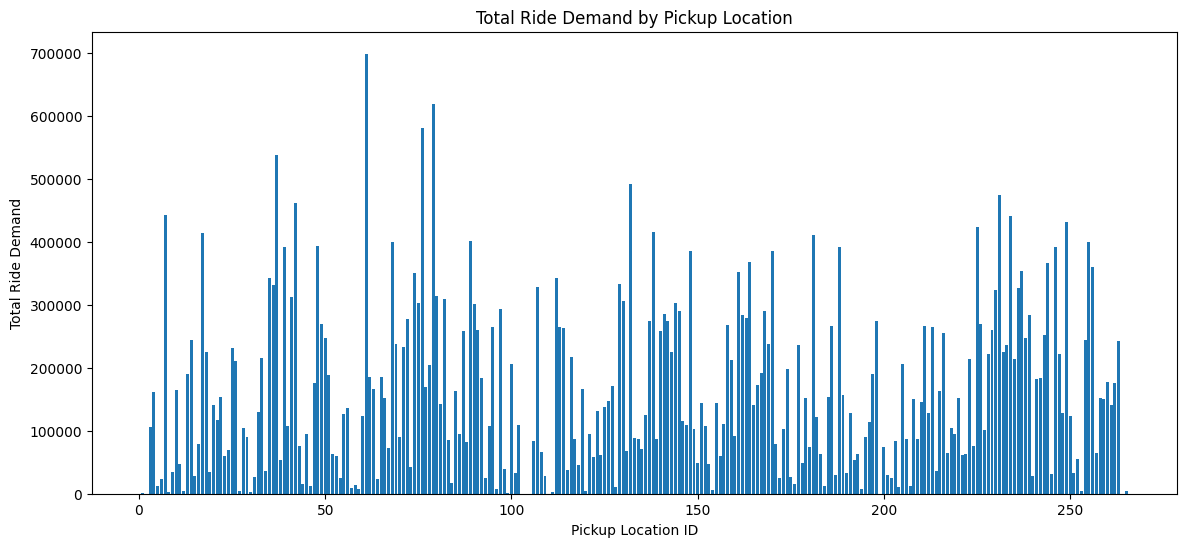

In [13]:
location_demand = (
    trip_df.groupby("PULocationID")["ride_count"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
plt.bar(location_demand.index, location_demand.values)

plt.xlabel("Pickup Location ID")
plt.ylabel("Total Ride Demand")
plt.title("Total Ride Demand by Pickup Location")

plt.show()

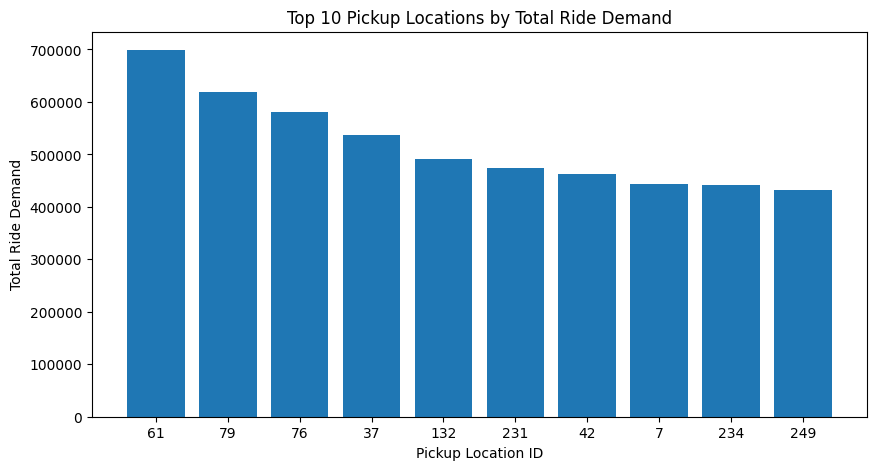

In [14]:
top_10_locations = (
    trip_df.groupby("PULocationID")["ride_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(
    top_10_locations.index.astype(str),
    top_10_locations.values
)

plt.xlabel("Pickup Location ID")
plt.ylabel("Total Ride Demand")
plt.title("Top 10 Pickup Locations by Total Ride Demand")

plt.show()

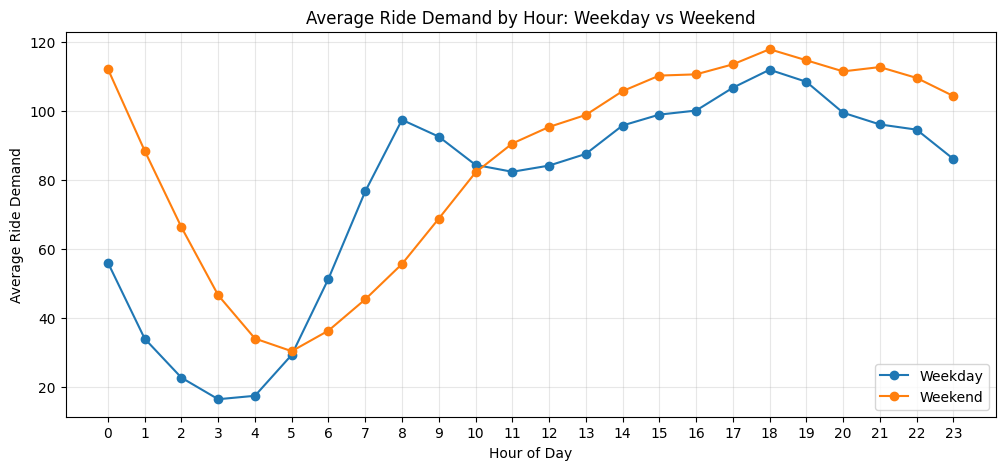

In [17]:
trip_df["hour"] = trip_df["pickup_hour"].dt.hour
trip_df["is_weekend"] = trip_df["pickup_hour"].dt.dayofweek >= 5

hour_weekend = (
    trip_df.groupby(["is_weekend", "hour"])["ride_count"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))

for weekend, data in hour_weekend.groupby("is_weekend"):
    label = "Weekend" if weekend else "Weekday"
    plt.plot(data["hour"], data["ride_count"], marker="o", label=label)

plt.xlabel("Hour of Day")
plt.ylabel("Average Ride Demand")
plt.title("Average Ride Demand by Hour: Weekday vs Weekend")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()